In [95]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import make_scorer, accuracy_score, mean_absolute_error, r2_score

## Get the Age and the Sex for each UKB subject

In [ ]:
a = pd.read_csv('/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/PCS_annotation/100_SEX_AGE_strat.csv')
a

#### Function to calculate the correlation between each dimension of the latent space and the age or the sex of the subjects

In [97]:
def get_corr_age_sex(df):
    # Get only the latent dimension columns
    latent_dims = [col for col in df.columns if col.startswith("dim")]

    # Correlation with Age
    age_corr = df[latent_dims].corrwith(df['Age'])

    # Correlation with Sex
    sex_corr = df[latent_dims].corrwith(df['Sex'])

    # Combine results into one DataFrame
    correlation_df = pd.DataFrame({
        'Correlation_with_Age': age_corr,
        'Correlation_with_Sex': sex_corr
    })

    # Display top correlations (absolute value)
    top_age_corr = correlation_df['Correlation_with_Age'].abs().sort_values(ascending=False).head()
    top_sex_corr = correlation_df['Correlation_with_Sex'].abs().sort_values(ascending=False).head()

    print("Top Age Correlations:\n", top_age_corr)
    print("Top Sex Correlations:\n", top_sex_corr)

In [98]:
def get_logistic_regression(df, column_name):
    # Define X and targets
    X = df[[f'dim{i}' for i in range(1, 257)]].values
    y = df['Sex'].values

    # 10-fold CV
    kf = KFold(n_splits=10, shuffle=True, random_state=42)

    # column_name – Logistic Regression
    log_reg = LogisticRegression(max_iter=1000, verbose=False)
    scores = cross_val_score(log_reg, X, y, cv=kf, scoring='accuracy')
    print(f"{column_name} classification accuracy (10-fold CV): {np.mean(scores):.3f} ± {np.std(scores):.3f}")

In [99]:
def get_multi_linear_regression(df, column_name, unit=''):
    # Define X and targets
    X = df[[f'dim{i}' for i in range(1, 257)]].values
    y = df[column_name].values

    # 10-fold CV
    kf = KFold(n_splits=10, shuffle=True, random_state=42)

    # AGE – Linear Regression with MAE
    lin_reg = LinearRegression()
    mae_scores = cross_val_score(lin_reg, X, y, cv=kf, scoring=make_scorer(mean_absolute_error))
    print(f"{column_name} prediction MAE ({unit}, 10-fold CV): {np.mean(mae_scores):.2f} ± {np.std(mae_scores):.2f}")

In [100]:
def get_multivariate_correlation(df, column_name, unit=''):
    X = df[[f'dim{i}' for i in range(1, 257)]].values
    y = df[column_name].values

    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    lin_reg = LinearRegression()

    # Cross-validated prediction
    y_pred = cross_val_predict(lin_reg, X, y, cv=kf)

    # Compute R²
    r2 = r2_score(y, y_pred)
    print(f"{column_name} prediction R² (10-fold CV): {r2:.3f}")

    # Optional: Also return MAE
    mae = np.mean(np.abs(y - y_pred))
    print(f"{column_name} prediction MAE ({unit}): {mae:.2f}")

In [101]:
def get_multi_space_correlation(df, column_name):
    X = df[[f'dim{i}' for i in range(1, 257)]].values
    y = df[column_name].values
    y_pred = cross_val_predict(LinearRegression(), X, y, cv=10)
    corr, pval = pearsonr(y, y_pred)
    print(f"Pearson correlation between predicted and actual {column_name}: r = {corr:.3f}, p = {pval:.3e}")

In [ ]:
sex_age_df = pd.read_csv("/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/participants_sex_age.csv")
sex_age_df

In [103]:
left_bdd_UKB = pd.read_csv("/neurospin/dico/adufournet/mycode/Output/CINGULATE_left/09-35-58_201/UKB40_trained_on_WBA_embeddings/full_embeddings.csv")
left_merge = pd.merge(sex_age_df, left_bdd_UKB, left_on='Subject', right_on='ID')
left_merge = left_merge.drop('ID', axis=1)

get_corr_age_sex(left_merge)

Top Age Correlations:
 dim44     0.080723
dim187    0.078737
dim23     0.077831
dim173    0.074141
dim250    0.069294
Name: Correlation_with_Age, dtype: float64
Top Sex Correlations:
 dim132    0.158526
dim200    0.156324
dim37     0.139705
dim81     0.135613
dim122    0.128640
Name: Correlation_with_Sex, dtype: float64


### Linear Multivariate regression on the latent space to predict the Age and the Sex (cross validation with 10 folds)

Sex classification accuracy (10-fold CV): 0.628 ± 0.008


Age prediction MAE (years, 10-fold CV): 6.16 ± 0.10

In [104]:
#get_logistic_regression(df=left_merge, column_name="Sex")
#
get_multi_linear_regression(df=left_merge, column_name='Age', unit='years')

Age prediction MAE (years, 10-fold CV): 6.16 ± 0.10


### Regression with known features in relation to the shape of the sulci (hull_junction_length_talairach, meandepth_talairach, maxdepth_talairach, surface_talairach)

In [105]:
list_of_features = ["hull_junction_length_talairach", "meandepth_talairach", "maxdepth_talairach", "surface_talairach", "GM_thickness",	"opening"]

In [106]:
left_FCMant = pd.read_csv("/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/sulcal_morphometry/UKB_F.C.M.ant._left.csv")
left_FCMant['IID'] = left_FCMant['IID'].apply(lambda x:'sub-'+str(x))
left_FCMant = left_FCMant[["IID"]+list_of_features]


left_SFint = pd.read_csv("/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/sulcal_morphometry/UKB_S.F.int._left.csv")
left_SFint['IID'] = left_SFint['IID'].apply(lambda x:'sub-'+str(x))
left_SFint = left_SFint[["IID"]+list_of_features]


left_merge_FCMant = pd.merge(left_merge, left_FCMant, left_on='Subject', right_on='IID')
left_merge_FCMant = left_merge_FCMant.dropna()


left_merge_SFint = pd.merge(left_merge, left_SFint, left_on='Subject', right_on='IID')
left_merge_SFint = left_merge_SFint.dropna()

In [107]:
for feature in list_of_features:
    #print(left_merge_FCMant[feature].describe())
    get_multivariate_correlation(df=left_merge_FCMant, column_name=feature, unit='mm')
    #get_multi_space_correlation(df=left_merge_FCMant, column_name=feature)
    print()

hull_junction_length_talairach prediction R² (10-fold CV): 0.219
hull_junction_length_talairach prediction MAE (mm): 20.96

meandepth_talairach prediction R² (10-fold CV): 0.336
meandepth_talairach prediction MAE (mm): 0.93

maxdepth_talairach prediction R² (10-fold CV): 0.180
maxdepth_talairach prediction MAE (mm): 1.54

surface_talairach prediction R² (10-fold CV): 0.258
surface_talairach prediction MAE (mm): 418.94

GM_thickness prediction R² (10-fold CV): 0.081
GM_thickness prediction MAE (mm): 0.29

opening prediction R² (10-fold CV): 0.094
opening prediction MAE (mm): 0.36



In [108]:
for feature in list_of_features:
    #print(left_merge_SFint[feature].describe())
    get_multivariate_correlation(df=left_merge_SFint, column_name=feature, unit='mm')
    #get_multi_space_correlation(df=left_merge_SFint, column_name=feature)
    print()

hull_junction_length_talairach prediction R² (10-fold CV): 0.281
hull_junction_length_talairach prediction MAE (mm): 27.52

meandepth_talairach prediction R² (10-fold CV): 0.459
meandepth_talairach prediction MAE (mm): 0.49

maxdepth_talairach prediction R² (10-fold CV): 0.227
maxdepth_talairach prediction MAE (mm): 1.31

surface_talairach prediction R² (10-fold CV): 0.391
surface_talairach prediction MAE (mm): 478.31

GM_thickness prediction R² (10-fold CV): 0.045
GM_thickness prediction MAE (mm): 0.22

opening prediction R² (10-fold CV): 0.115
opening prediction MAE (mm): 0.33



Text(0.5, 1.0, 'Correlation between the dimensions of the latent space representing the left ACC')

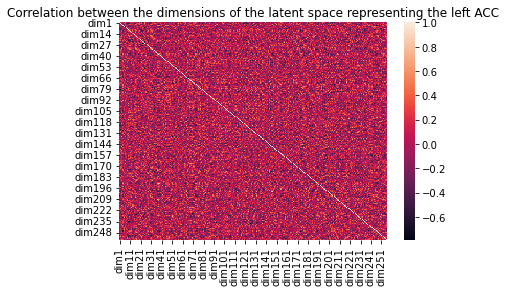

In [115]:
sns.heatmap(left_bdd_UKB.drop('ID', axis=1).corr())
plt.title('Correlation between the dimensions of the latent space representing the left ACC')

In [109]:
right_bdd_UKB = pd.read_csv("/neurospin/dico/adufournet/mycode/Output/CINGULATE_right/14-27-09_138/UKB40_trained_on_WBA_embeddings/full_embeddings.csv")
right_merge = pd.merge(sex_age_df, right_bdd_UKB, left_on='Subject', right_on='ID')
right_merge = right_merge.drop('ID', axis=1)

get_corr_age_sex(right_merge)

Top Age Correlations:
 dim53     0.087972
dim7      0.079955
dim92     0.076089
dim198    0.070985
dim168    0.064238
Name: Correlation_with_Age, dtype: float64
Top Sex Correlations:
 dim9      0.126993
dim64     0.121045
dim124    0.116243
dim54     0.109899
dim71     0.105806
Name: Correlation_with_Sex, dtype: float64


In [114]:
get_logistic_regression(df=right_merge, column_name="Sex")

get_multi_linear_regression(df=right_merge, column_name='Age', unit='years')

/usr/lib/python3/dist-packages/sklearn/linear_model/_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/lib/python3/dist-packages/sklearn/linear_model/_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_resu

Sex classification accuracy (10-fold CV): 0.616 ± 0.006
Age prediction MAE (years, 10-fold CV): 6.25 ± 0.07


In [111]:
right_FCMant = pd.read_csv("/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/sulcal_morphometry/UKB_F.C.M.ant._right.csv")
right_FCMant['IID'] = right_FCMant['IID'].apply(lambda x:'sub-'+str(x))

right_SFint = pd.read_csv("/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/sulcal_morphometry/UKB_S.F.int._right.csv")
right_SFint['IID'] = right_SFint['IID'].apply(lambda x:'sub-'+str(x))

right_merge_FCMant = pd.merge(right_merge, right_FCMant, left_on='Subject', right_on='IID')
right_merge_FCMant = right_merge_FCMant.dropna()

right_merge_SFint = pd.merge(right_merge, right_SFint, left_on='Subject', right_on='IID')
right_merge_SFint = right_merge_SFint.dropna()

In [112]:
for feature in list_of_features:
    #print(right_merge_SFint[feature].describe())
    get_multivariate_correlation(df=right_merge_SFint, column_name=feature, unit='mm')
    #get_multi_space_correlation(df=right_merge_SFint, column_name=feature)
    print()

hull_junction_length_talairach prediction R² (10-fold CV): 0.275
hull_junction_length_talairach prediction MAE (mm): 29.85

meandepth_talairach prediction R² (10-fold CV): 0.366
meandepth_talairach prediction MAE (mm): 0.53

maxdepth_talairach prediction R² (10-fold CV): 0.116
maxdepth_talairach prediction MAE (mm): 1.46

surface_talairach prediction R² (10-fold CV): 0.317
surface_talairach prediction MAE (mm): 553.18

GM_thickness prediction R² (10-fold CV): 0.031
GM_thickness prediction MAE (mm): 0.22

opening prediction R² (10-fold CV): 0.087
opening prediction MAE (mm): 0.36



In [113]:
for feature in list_of_features:
    #print(right_merge_FCMant[feature].describe())
    get_multivariate_correlation(df=right_merge_FCMant, column_name=feature, unit='mm')
    #get_multi_space_correlation(df=right_merge_FCMant, column_name=feature)
    print()

hull_junction_length_talairach prediction R² (10-fold CV): 0.236
hull_junction_length_talairach prediction MAE (mm): 19.87

meandepth_talairach prediction R² (10-fold CV): 0.382
meandepth_talairach prediction MAE (mm): 1.06

maxdepth_talairach prediction R² (10-fold CV): 0.294
maxdepth_talairach prediction MAE (mm): 1.62

surface_talairach prediction R² (10-fold CV): 0.330
surface_talairach prediction MAE (mm): 409.14

GM_thickness prediction R² (10-fold CV): 0.079
GM_thickness prediction MAE (mm): 0.31

opening prediction R² (10-fold CV): 0.072
opening prediction MAE (mm): 0.38



Text(0.5, 1.0, 'Correlation between the dimensions of the latent space representing the right ACC')

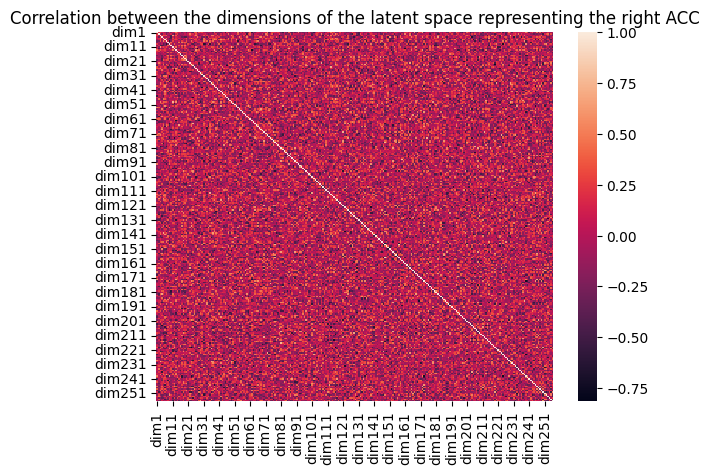

In [21]:
sns.heatmap(right_bdd_UKB.drop('ID', axis=1).corr())
plt.title('Correlation between the dimensions of the latent space representing the right ACC')